# dowload dataset and install dependencies

In [ ]:
!gdown --id 1CCqXyceBmIrtaqlUcVwuYMshxCfB_RM3

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1CCqXyceBmIrtaqlUcVwuYMshxCfB_RM3
From (redirected): https://drive.google.com/uc?id=1CCqXyceBmIrtaqlUcVwuYMshxCfB_RM3&confirm=t&uuid=b9ee1fca-5b04-4c68-932a-4f1c3fde6a8c
To: /content/vqa_coco_dataset.zip
100% 196M/196M [00:03<00:00, 57.8MB/s]


In [ ]:
!unzip "./vqa_coco_dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: val2014-resised/COCO_val2014_000000227893.jpg  
  inflating: val2014-resised/COCO_val2014_000000227901.jpg  
  inflating: val2014-resised/COCO_val2014_000000227952.jpg  
  inflating: val2014-resised/COCO_val2014_000000227960.jpg  
  inflating: val2014-resised/COCO_val2014_000000228013.jpg  
  inflating: val2014-resised/COCO_val2014_000000228135.jpg  
  inflating: val2014-resised/COCO_val2014_000000228166.jpg  
  inflating: val2014-resised/COCO_val2014_000000228306.jpg  
  inflating: val2014-resised/COCO_val2014_000000228436.jpg  
  inflating: val2014-resised/COCO_val2014_000000228464.jpg  
  inflating: val2014-resised/COCO_val2014_000000228506.jpg  
  inflating: val2014-resised/COCO_val2014_000000228541.jpg  
  inflating: val2014-resised/COCO_val2014_000000228552.jpg  
  inflating: val2014-resised/COCO_val2014_000000228580.jpg  
  inflating: val2014-resised/COCO_val2014_000000228749.jpg  
  inflating: val2014-resised/COCO_

In [ ]:
!pip install timm==0.8.17.dev0
!pip install torchtext==0.15.1
!pip install torchvision==0.16.0
!pip install torchaudio==2.1.0
!pip install torch==2.1.0
!pip install transformers==4.27.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.9 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.12
    Uninstalling timm-1.0.12:
      Successfully uninstalled timm-1.0.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 2.

# CNN and LSTM

## import and set random seed

In [ ]:
import torch
import torch.nn as nn
import torchtext
import os
import random
import numpy as np
import pandas as pd
import spacy
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchvision import transforms

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
seed = 59
set_seed(seed)

## prepare data

In [ ]:
def get_data(path):
  data = []
  with open(path,"r") as f:
    lines = f.readlines()
    for line in lines:
      temp = line.split("\t")
      qa = temp[1].split("?")

      if len(qa) ==3:
        answer = qa[2].strip()
      else:
        answer = qa[1].strip()

        data_sample = {
          "image_path":temp[0][:-2],
          "question": qa[0] + "?",
          "answer": answer
        }
        data.append(data_sample)
  return data
train_set_path = "./vaq2.0.TrainImages.txt"
val_set_path = "./vaq2.0.DevImages.txt"
test_set_path = "./vaq2.0.TestImages.txt"

train_data = get_data(train_set_path)
val_data = get_data(val_set_path)
test_data = get_data(test_set_path)

In [ ]:
eng = spacy.load("en_core_web_sm")

def get_tokens(data_iter):
  for sample in data_iter:
    question = sample['question']
    yield [token.text for token in eng.tokenizer(question)]
vocab = build_vocab_from_iterator(get_tokens(train_data), min_freq=2, specials=["<pad>","<sos>","<eos>","<unk>"],special_first=True)
vocab.set_default_index(vocab["<unk>"])

In [ ]:
classes = set([sample['answer'] for sample in train_data])
label2idx = {
    cls_name:idx for idx,cls_name in enumerate(classes)
}
idx2label = {
    idx:cls_name for idx,cls_name in enumerate(classes)
}

In [ ]:
def tokenize(question,max_seq_len):
  tokens = [token.text for token in eng.tokenizer(question)]
  sequence = [vocab[token] for token in tokens]
  if len(sequence) < max_seq_len:
    sequence +=[vocab['pad']]*(max_seq_len-len(sequence))
  else:
    sequence = sequence[:max_seq_len]
  return sequence


In [ ]:
class VQADataset(Dataset):
  def __init__(self,data,label2idx,max_seq_len=20,transform=None,img_dir="val2014-resised/"):
    self.transform = transform
    self.data = data
    self.max_seq_len = max_seq_len
    self.img_dir = img_dir
    self.label2idx = label2idx
  def __len__(self):
    return len(self.data)
  def __getitem__(self,index):
    img_path = os.path.join(self.img_dir,self.data[index]['image_path'])
    img = Image.open(img_path).convert("RGB")
    if self.transform:
      img =self.transform(img)
    question = self.data[index]['question']
    question = tokenize(question,self.max_seq_len)
    question = torch.tensor(question,dtype=torch.long)

    label = self.data[index]['answer']
    label = label2idx[label]
    label = torch.tensor(label,dtype=torch.long)
    return img,question,label


In [ ]:
data_transform = {
    "train":transforms.Compose([
        transforms.Resize(size=(224,224)),
        transforms.CenterCrop(size=180),
        transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.GaussianBlur(3),
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ]),
    "val":transforms.Compose([
        transforms.Resize(size=(224,224)),
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ])
}

In [ ]:
train_dataset = VQADataset(
    train_data,
    label2idx,
    transform=data_transform["train"]
)
val_dataset = VQADataset(
    val_data,
    label2idx,
    transform=data_transform["val"]
)
test_dataset = VQADataset(
    test_data,
    label2idx,
    transform=data_transform["val"]
)

In [ ]:
train_batch_size=256
test_batch_size=32

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=train_batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=train_batch_size,
    shuffle=False
)

## Model

In [ ]:
class VQAModel(nn.Module):
  def __init__(self,n_classes,img_model_name,embedding_dim,n_layers=2,hidden_size=256,drop_p=0.2):
    super().__init__()
    self.image_encoder = timm.create_model(img_model_name,pretrained=True,num_classes=hidden_size)

    for param in self.image_encoder.parameters():
      param.requires_grad = True

    self.embedding = nn.Embedding(len(vocab),embedding_dim)

    self.lstm1 = nn.LSTM(
        input_size=embedding_dim,
        hidden_size=hidden_size,
        num_layers=n_layers,
        batch_first=True,
        dropout=drop_p,
        bidirectional=True
    )

    self.fc1 = nn.Linear(hidden_size*3,hidden_size)
    self.dropout = nn.Dropout(drop_p)
    self.gelu = nn.GELU()
    self.fc2 = nn.Linear(hidden_size,n_classes)

  def forward(self,img,text):
    img_features = self.image_encoder(img)

    text_emb = self.embedding(text)
    lstm_out,_ = self.lstm1(text_emb)

    lstm_out = lstm_out[:,-1,:]

    combined = torch.cat((img_features,lstm_out),dim=1)
    x = self.fc1(combined)
    x = self.gelu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    return x


In [ ]:
n_classes = len(classes)
img_model_name = "resnet18"
hidden_size=256
n_layers = 2
embedding_dim = 128
drop_p =0.2
device = "cuda" if torch.cuda.is_available() else"cpu"

model = VQAModel(
    n_classes=n_classes,
    embedding_dim = embedding_dim,
    img_model_name = img_model_name,
    hidden_size = hidden_size,
    n_layers = n_layers,
    drop_p = drop_p
).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


## Train

In [ ]:
def evaluate(model,dataloader,criterion,device):
  model.eval()
  correct = 0
  total = 0
  losses = []
  with torch.no_grad():
    for image, question,labels in dataloader:
      image,question,labels = image.to(device), question.to(device),labels.to(device)
      outputs = model(image,question)
      loss = criterion(outputs,labels)
      losses.append(loss.item())
      _,predicted = torch.max(outputs.data,1)
      total +=labels.size(0)
      correct +=(predicted == labels).sum().item()
  loss = sum(losses)/len(losses)
  acc = correct/total

  return loss,acc

def fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs):
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    batch_train_losses = []

    model.train()

    for idx,(images,questions,labels) in enumerate(train_loader):
      images = images.to(device)
      questions = questions.to(device)
      labels = labels.to(device)
      optimizer.zero_grad()
      outputs = model(images,questions)
      loss = criterion(outputs,labels)

      loss.backward()
      optimizer.step()

      batch_train_losses.append(loss.item())
    train_loss = sum(batch_train_losses)/len(batch_train_losses)

    train_losses.append(train_loss)

    val_loss,val_acc =evaluate(model,val_loader,criterion,device)
    val_losses.append(val_loss)

    print(f"EPOCH {epoch +1}: \tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tVal Acc: {val_acc}")

    scheduler.step()
  return train_losses, val_losses

In [ ]:
lr = 1e-3
epochs = 50
scheduler_step_size = epochs *0.8
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=scheduler_step_size,gamma=0.1
)


In [ ]:
train_losses,val_losses = fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs)

EPOCH 1: 	Train loss: 0.6977	Val loss: 0.7614	Val Acc: 0.5084572014351615
EPOCH 2: 	Train loss: 0.6932	Val loss: 0.6948	Val Acc: 0.5238339313172732
EPOCH 3: 	Train loss: 0.6932	Val loss: 0.6935	Val Acc: 0.5099948744233727
EPOCH 4: 	Train loss: 0.6904	Val loss: 0.6903	Val Acc: 0.5361353152229625
EPOCH 5: 	Train loss: 0.6929	Val loss: 0.6955	Val Acc: 0.47565351101998976
EPOCH 6: 	Train loss: 0.6933	Val loss: 0.7322	Val Acc: 0.5417734495130703
EPOCH 7: 	Train loss: 0.6917	Val loss: 0.7471	Val Acc: 0.49308047155304974
EPOCH 8: 	Train loss: 0.6916	Val loss: 0.6915	Val Acc: 0.5289595079446437
EPOCH 9: 	Train loss: 0.6907	Val loss: 0.6886	Val Acc: 0.5392106611993849
EPOCH 10: 	Train loss: 0.6910	Val loss: 0.6938	Val Acc: 0.5376729882111737
EPOCH 11: 	Train loss: 0.6901	Val loss: 0.6896	Val Acc: 0.5392106611993849
EPOCH 12: 	Train loss: 0.6911	Val loss: 0.6900	Val Acc: 0.5366478728856996
EPOCH 13: 	Train loss: 0.6895	Val loss: 0.6916	Val Acc: 0.5299846232701179
EPOCH 14: 	Train loss: 0.6891	Va

## Evaluation

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

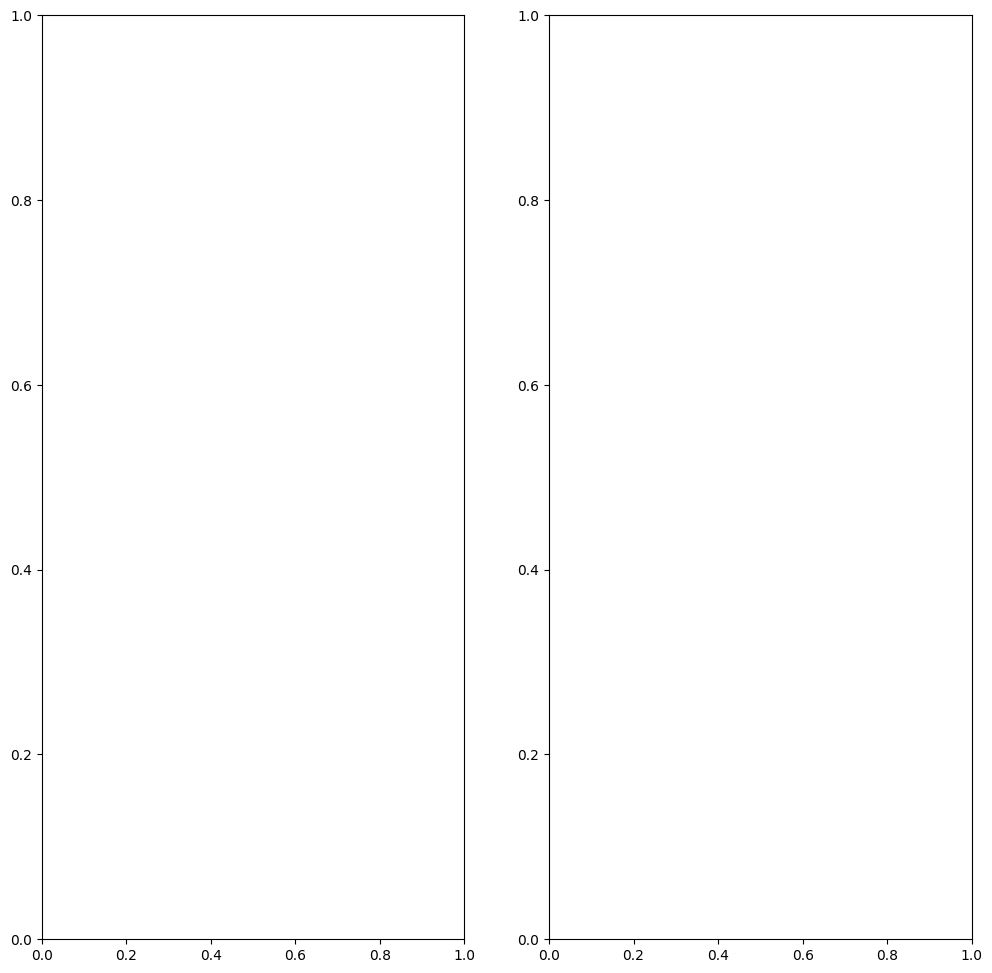

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(np.arange(epochs),train_losses,color="orange")
ax[0].set_title("Train Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")

ax[1].plot(np.arange(epochs),val_losses,color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

In [ ]:
val_loss,val_acc = evaluate(model,val_loader,criterion,device)

test_loss,test_acc = evaluate(model,test_loader,criterion,device)


print("Evaluation on val/test dataset")
print("Val accuracy: ", val_acc)
print("Test accuracy: ",test_acc)

# Vision Transformers + RoBERTa

## Import libraries and set random seed

In [ ]:
import torch
import torch.nn as nn
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel, ViTImageProcessor
from transformers import AutoTokenizer, RobertaModel

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
seed = 59
set_seed(seed)

## Prepare Data

In [ ]:
def get_data(path):
  data = []
  with open(path,"r") as f:
    lines = f.readlines()
    for line in lines:
      temp = line.split("\t")
      qa = temp[1].split("?")

      if len(qa) ==3:
        answer = qa[2].strip()
      else:
        answer = qa[1].strip()

        data_sample = {
          "image_path":temp[0][:-2],
          "question": qa[0] + "?",
          "answer": answer
        }
        data.append(data_sample)
  return data
train_set_path = "./vaq2.0.TrainImages.txt"
val_set_path = "./vaq2.0.DevImages.txt"
test_set_path = "./vaq2.0.TestImages.txt"

train_data = get_data(train_set_path)
val_data = get_data(val_set_path)
test_data = get_data(test_set_path)

In [ ]:
classes = set([sample['answer'] for sample in train_data])
label2idx = {
    cls_name:idx for idx,cls_name in enumerate(classes)
}
idx2label = {
    idx:cls_name for idx,cls_name in enumerate(classes)
}

In [ ]:
class VQADataset(Dataset):
  def __init__(self,data,label2idx,img_feature_extractor,text_tokenizer,device,transform=None,img_dir="val2014-resised/"):
    self.transform = transform
    self.data = data
    self.img_feature_extractor = img_feature_extractor
    self.text_tokenizer = text_tokenizer
    self.device = device
    self.img_dir = img_dir
    self.label2idx = label2idx
  def __len__(self):
    return len(self.data)
  def __getitem__(self,index):
    img_path = os.path.join(self.img_dir,self.data[index]['image_path'])
    img = Image.open(img_path).convert("RGB")
    if self.transform:
      img =self.transform(img)
    if self.img_feature_extractor:
      img = self.img_feature_extractor(images=img,return_tensors="pt")
      img = {k:v.to(self.device).squeeze(0) for k,v in img.items()}

    question = self.data[index]['question']
    if self.text_tokenizer:
      question = self.text_tokenizer(
          question,
          padding="max_length",
          max_length=20,
          truncation=True,
          return_tensors="pt"
      )
      question = {k:v.to(self.device).squeeze(0) for k,v in question.items()}


    label = self.data[index]['answer']
    label = torch.tensor(self.label2idx[label],dtype=torch.long).to(device)
    label = torch.tensor(label,dtype=torch.long)
    sample = {
        "image":img,
        "question":question,
        "label":label
    }
    return sample

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.CenterCrop(size=180),
    transforms.ColorJitter(brigtness=0.1,contrast=0.1,saturation=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(3),
])

In [ ]:
img_feature_extractor = ViTImageProcessor.from_pretrained("google,vit-base-patch16-224")
text_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

device = "cuda" if torch.cuda.is_available() else "cpi"

train_dataset = VQADataset(
    train_data,
    label2idx = label2idx,
    img_feature_extractor = img_feature_extractor,
    text_tokenizer = text_tokenizer,
    device = device,
    transform=data_transform
)
val_dataset = VQADataset(
    val_data,
    label2idx = label2idx,
    img_feature_extractor = img_feature_extractor,
    text_tokenizer = text_tokenizer,
    device = device,
)
test_dataset = VQADataset(
    test_data,
    label2idx = label2idx,
    img_feature_extractor = img_feature_extractor,
    text_tokenizer = text_tokenizer,
    device = device,
)

In [ ]:
train_batch_size=  256
test_batch_size= 32

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)
train_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

## Model

In [ ]:
# Text Encoer
class TextEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = RobertaModel.from_pretrained("roberta-base")
  def forward(self,inputs):
    outputs = self.model(**inputs)

    return outputs.pooler_output
# Visual Encoder
class VisualEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = ViTModel.from_pretrained("google/vit-base-patch16-224")
  def forward(self,inputs):
    outputs = self.model(**inputs)

    return outputs.pooler_output
# Classifier
class Classifier(nn.Module):
  def __init__(self,hidden_size=512,dropout_prob=0.2,n_classes=2):
    super().__init__()
    self.fc1 = nn.Linear(768*2,hidden_size)
    self.gelu = nn.GELU()
    self.dropout = nn.Dropout(dropout_prob)
    self.fc2 = nn.linear(hidden_size,n_classes)
  def forward(self,x):
    x = self.fc1(x)
    x = self.gelu(x)
    x = self.dropout(x)
    x=  self.fc2(x)
    return x


In [ ]:
class VQAModel(nn.Module):
  def __init__(self,visual_encoder,text_encoder,classifier):
    super().__init__()
    self.visual_encoder = visual_encoder
    self.text_encoder = text_encoder
    self.classifier = classifier
  def forward(self,image,answer):
    text_out = self.text_encoder(answer)
    image_out = self.visual_encoder(image)
    x = torch.cat((image_out,text_out),dim=1)
    x = self.classifier(x)
    return x
  def freeze(self,visual=True,textual=True,clas=False):
    if visual:
      for n,p in self.visual_encoder.named_parameters():
        p.requires_grad=  False
    if textual:
      for n,p in self.text_encoder.named_parameters():
        p.requires_grad=  False
    if clas:
      for n,p in self.classifier.named_parameters():
        p.requires_grad=  False

In [ ]:
n_classes = len(classes)
hidden_size = 256
dropout_prob = 0.2

text_encoder = TextEncoder().to(device)
visual_encoder = VisualEncoder().to(device)
classifier = Classifier(
    hidden_size=hidden_size,
    dropout_prob = dropout_prob,
    n_classes = n_classes
).to(device)

model = VQAModel(
    visual_encoder=visual_encoder,
    text_encoder=text_encoder,
    classifier=classifier
).to(device)
model.freeze()


## Train

In [ ]:
def evaluate(model,dataloader,criterion,device):
  model.eval()
  correct = 0
  total = 0
  losses = []
  with torch.no_grad():
    for idx,inputs in enumerate(dataloader):
      images = inputs['image']
      questions = inputs['question']
      labels = inputs['label']
      outputs = model(image,question)
      loss = criterion(outputs,labels)
      losses.append(loss.item())
      _,predicted = torch.max(outputs.data,1)
      total +=labels.size(0)
      correct +=(predicted == labels).sum().item()
  loss = sum(losses)/len(losses)
  acc = correct/total

  return loss,acc

def fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs):
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    batch_train_losses = []

    model.train()

    for idx,inputs in enumerate(train_loader):
      images = inputs['image']
      questions = inputs['question']
      labels = inputs['label']
      optimizer.zero_grad()
      outputs = model(images,questions)
      loss = criterion(outputs,labels)

      loss.backward()
      optimizer.step()

      batch_train_losses.append(loss.item())
    train_loss = sum(batch_train_losses)/len(batch_train_losses)

    train_losses.append(train_loss)

    val_loss,val_acc =evaluate(model,val_loader,criterion,device)
    val_losses.append(val_loss)

    print(f"EPOCH {epoch +1}: \tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tVal Acc: {val_acc}")

    scheduler.step()
  return train_losses, val_losses

In [ ]:
lr = 1e-3
epochs = 50
scheduler_step_size = epochs *0.8
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=scheduler_step_size,gamma=0.1
)


In [ ]:
train_losses,val_losses = fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs)

## Evaluation

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(np.arange(epochs),train_losses,color="orange")
ax[0].set_title("Train Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")

ax[1].plot(np.arange(epochs),val_losses,color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

In [ ]:
val_loss,val_acc = evaluate(model,val_loader,criterion,device)

test_loss,test_acc = evaluate(model,test_loader,criterion,device)


print("Evaluation on val/test dataset")
print("Val accuracy: ", val_acc)
print("Test accuracy: ",test_acc)

# Vision-Language Models

## Import libraries and set random seed

In [ ]:
import torch
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from transformers import LlavaForConditionalGeneration
from transformers import AutoProcessor
from transformers import BitsAndBytesConfig
from transformers import GenerationConfig

## Prepare Data

In [ ]:
def get_data(path):
  data = []
  with open(path,"r") as f:
    lines = f.readlines()
    for line in lines:
      temp = line.split("\t")
      qa = temp[1].split("?")

      if len(qa) ==3:
        answer = qa[2].strip()
      else:
        answer = qa[1].strip()

        data_sample = {
          "image_path":temp[0][:-2],
          "question": qa[0] + "?",
          "answer": answer
        }
        data.append(data_sample)
  return data
train_set_path = "./vaq2.0.TrainImages.txt"
val_set_path = "./vaq2.0.DevImages.txt"
test_set_path = "./vaq2.0.TestImages.txt"

train_data = get_data(train_set_path)
val_data = get_data(val_set_path)
test_data = get_data(test_set_path)

## Model

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_compute_dtype=torch.float16
)

model_id = "llava-hf/llava-1.5-7b-hf"
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config= quantization_config,
    device_map="device"
)

In [ ]:
def create_prompt(question):
  prompt = f"""### INSTRUCTION:
  Your task is to answer the question based on the given image. You can only answer 'yes' or 'no'.
  ### USER: <image>
  {question}
  ### ASSISTANT:"""
  return prompt

In [ ]:
generation_config = GenerationConfig(
    max_new_tokens=10,
    do_sample=True,
    temperature=0.1,
    top_p=0.95,
    top_k=50,
    eos_token_id=model.config.eos_token_id,
    pad_token=model.config.pad_token_id
)

In [ ]:
idx = 0
question = test_data[idx]['question']
image_name = test_data[idx]['image_path']
image_path = os.path.join("val2014-resised",image_name)
label = test_data[idx]['answer']
image = Image.open(image_path)

prompt = create_prompt(question)
inputs = processor(prompt,image,padding=True,return_tensors="pt").to(device)
output = model.generate(**inputs,generation_config=generation_config)
generated_text = processor.decode(output[0],skip_special_tokens=True)

plt.imshow(image)
plt.axis("off")
plt.show()
print(f"Question: {question}")
print(f"Label: {label}")
print(f"Prediction: {generated_text.split("### ASSISTANT:")[-1]}")